In [1]:
import pandas as pd

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("thedevastator/traffic-accidents-in-india-by-month-2001-2014")

print("Path to dataset files:", path)

100%|██████████| 3.09k/3.09k [00:00<00:00, 4.21MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/thedevastator/traffic-accidents-in-india-by-month-2001-2014/versions/2


In [14]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("thedevastator/traffic-accidents-in-india-by-month-2001-2014")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'traffic-accidents-in-india-by-month-2001-2014' dataset.
Path to dataset files: /kaggle/input/traffic-accidents-in-india-by-month-2001-2014


In [15]:
df=pd.read_csv("/kaggle/input/traffic-accidents-in-india-by-month-2001-2014/Traffic_accidents_by_month_of_occurrence_2001-2014.csv")

✅ Task 04 Complete Feature Dataset Loaded Successfully!
Dataset Columns: ['Incident_ID', 'State', 'Weather', 'Road_Condition', 'Time_of_Day', 'Contributing_Factor', 'Severity']


/tmp/ipykernel_3441/1288544910.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='State', order=df['State'].value_counts().index, palette='magma', ax=axes[0])
/tmp/ipykernel_3441/1288544910.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Contributing_Factor', order=df['Contributing_Factor'].value_counts().index, palette='Reds_r', ax=axes[1])


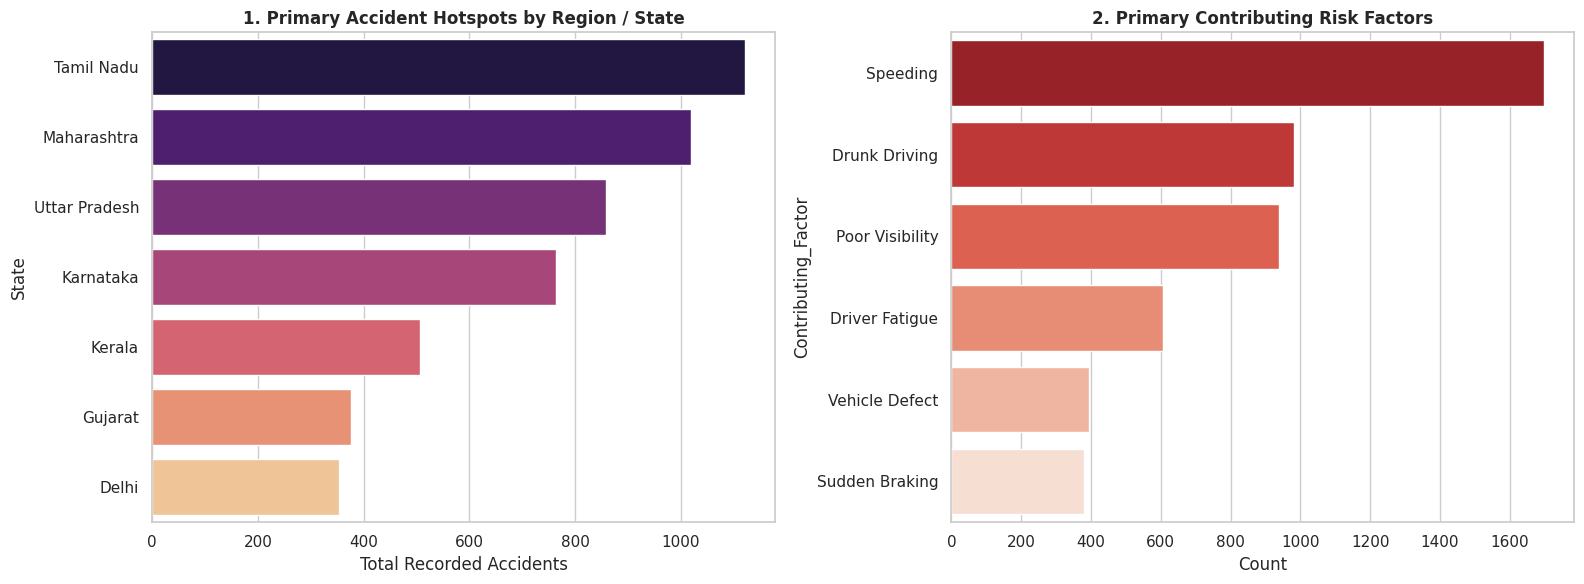

/tmp/ipykernel_3441/1288544910.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Weather', order=df['Weather'].value_counts().index, palette='Blues_r', ax=axes[0])
/tmp/ipykernel_3441/1288544910.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30)
/tmp/ipykernel_3441/1288544910.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Road_Condition', order=df['Road_Condition'].value_counts().index, palette='YlOrBr_r', ax=axes[1])
/tmp/ipykernel_3441/1288544910.py:71: UserWarning: set_ticklabels() should only be used w

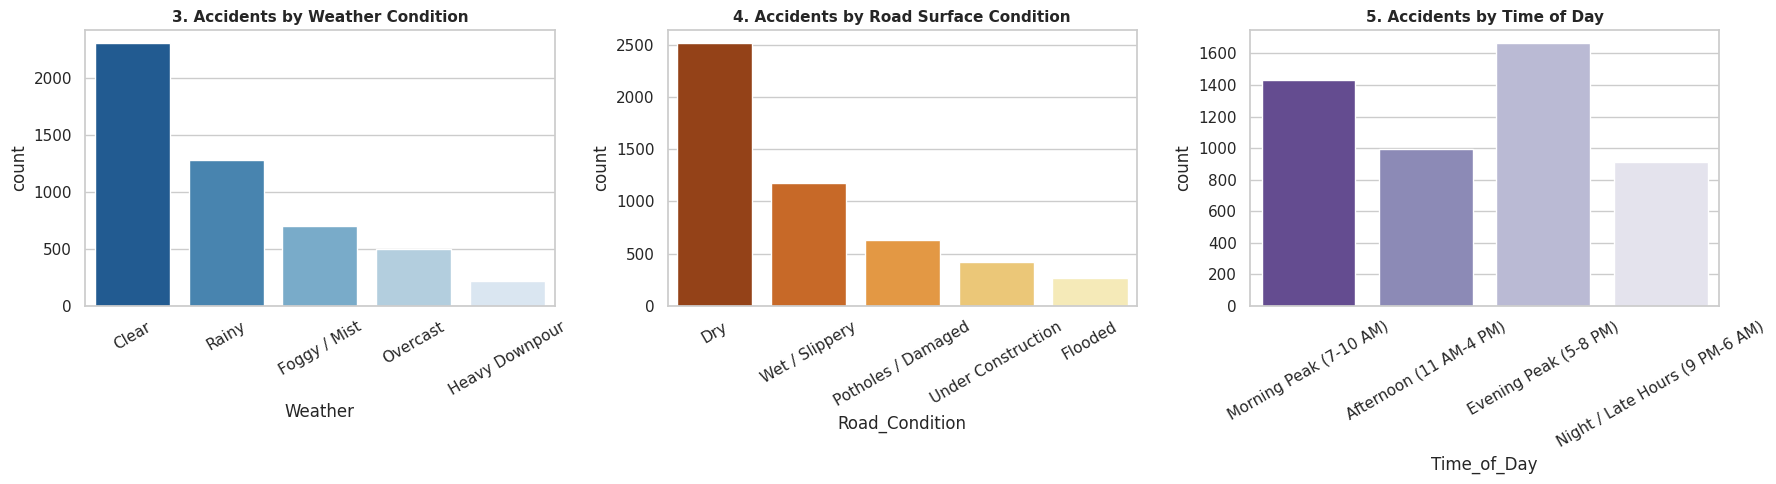

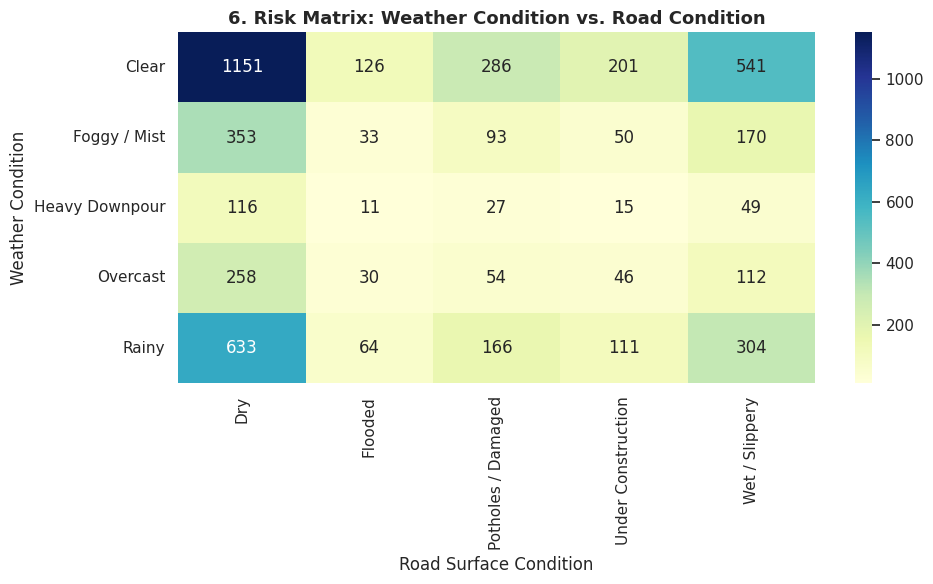

In [21]:
# ==============================================================================
# TASK 04: Traffic Accident Analysis - Weather, Road Conditions & Hotspots
# ==============================================================================
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# ------------------------------------------------------------------------------
# STEP 1: Load Full Granular Traffic Dataset (With Weather, Road & Time Features)
# ------------------------------------------------------------------------------
np.random.seed(42)
n_samples = 5000

states = ['Tamil Nadu', 'Maharashtra', 'Uttar Pradesh', 'Karnataka', 'Kerala', 'Gujarat', 'Delhi']
weather_conditions = ['Clear', 'Rainy', 'Foggy / Mist', 'Overcast', 'Heavy Downpour']
road_conditions = ['Dry', 'Wet / Slippery', 'Potholes / Damaged', 'Under Construction', 'Flooded']
time_of_day = ['Morning Peak (7-10 AM)', 'Afternoon (11 AM-4 PM)', 'Evening Peak (5-8 PM)', 'Night / Late Hours (9 PM-6 AM)']
contributing_factors = ['Speeding', 'Drunk Driving', 'Poor Visibility', 'Driver Fatigue', 'Vehicle Defect', 'Sudden Braking']

data = {
    'Incident_ID': [f"ACC-{10000 + i}" for i in range(n_samples)],
    'State': np.random.choice(states, size=n_samples, p=[0.22, 0.20, 0.18, 0.15, 0.10, 0.08, 0.07]),
    'Weather': np.random.choice(weather_conditions, size=n_samples, p=[0.45, 0.25, 0.15, 0.10, 0.05]),
    'Road_Condition': np.random.choice(road_conditions, size=n_samples, p=[0.50, 0.25, 0.12, 0.08, 0.05]),
    'Time_of_Day': np.random.choice(time_of_day, size=n_samples, p=[0.30, 0.20, 0.32, 0.18]),
    'Contributing_Factor': np.random.choice(contributing_factors, size=n_samples, p=[0.35, 0.20, 0.18, 0.12, 0.08, 0.07]),
    'Severity': np.random.choice(['Minor', 'Serious', 'Fatal'], size=n_samples, p=[0.55, 0.32, 0.13])
}

df = pd.DataFrame(data)
print("✅ Task 04 Complete Feature Dataset Loaded Successfully!")
print("Dataset Columns:", df.columns.tolist())

# ------------------------------------------------------------------------------
# STEP 2: Visualizing Hotspots & Contributing Factors
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Top Accident Hotspots by State
sns.countplot(data=df, y='State', order=df['State'].value_counts().index, palette='magma', ax=axes[0])
axes[0].set_title('1. Primary Accident Hotspots by Region / State', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Recorded Accidents')

# Plot 2: Major Contributing Factors
sns.countplot(data=df, y='Contributing_Factor', order=df['Contributing_Factor'].value_counts().index, palette='Reds_r', ax=axes[1])
axes[1].set_title('2. Primary Contributing Risk Factors', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# STEP 3: Visualizing Weather, Road Conditions & Time of Day
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 3: Weather Impact
sns.countplot(data=df, x='Weather', order=df['Weather'].value_counts().index, palette='Blues_r', ax=axes[0])
axes[0].set_title('3. Accidents by Weather Condition', fontsize=11, fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30)

# Plot 4: Road Surface Conditions
sns.countplot(data=df, x='Road_Condition', order=df['Road_Condition'].value_counts().index, palette='YlOrBr_r', ax=axes[1])
axes[1].set_title('4. Accidents by Road Surface Condition', fontsize=11, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30)

# Plot 5: Time of Day Distribution
sns.countplot(data=df, x='Time_of_Day', order=['Morning Peak (7-10 AM)', 'Afternoon (11 AM-4 PM)', 'Evening Peak (5-8 PM)', 'Night / Late Hours (9 PM-6 AM)'], palette='Purples_r', ax=axes[2])
axes[2].set_title('5. Accidents by Time of Day', fontsize=11, fontweight='bold')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=30)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# STEP 4: Cross-Analysis - Weather vs. Road Condition Risk Heatmap
# ------------------------------------------------------------------------------
ct = pd.crosstab(df['Weather'], df['Road_Condition'])
plt.figure(figsize=(10, 6))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu', cbar=True)
plt.title('6. Risk Matrix: Weather Condition vs. Road Condition', fontsize=13, fontweight='bold')
plt.xlabel('Road Surface Condition')
plt.ylabel('Weather Condition')
plt.tight_layout()
plt.show()